In [5]:
import sys
from pathlib import Path
repo_root = Path.cwd().resolve().parents[0]
sys.path.append(str(repo_root))

from transaction_gan.config import SchemaConfig
from transaction_gan.pipeline import generate_synthetic_transactions

In [6]:
schema = SchemaConfig(
    id_column="transaction_id",
    geo_column="transaction_address",
    date_column="transaction_date",
    continuous_columns=["amount", "customer_age"],
    categorical_columns=["merchant_category", "transaction_type", "merchant_code", "is_fraud"],
    drop_columns=["transaction_id"],
)

In [7]:
result = generate_synthetic_transactions(
    data_path=Path("data/sample_transactions.csv"),
    output_path=Path("data/synthetic_transactions.csv"),
    schema=schema,
    samples_to_generate=512,
)

In [8]:
result

{'analysis': {'numeric': {'amount': {'mean': 2486.6259629999936,
    'std': 1445.601268246313,
    'min': 1.03,
    'max': 4998.77},
   'customer_age': {'mean': 51.3746,
    'std': 19.823477869435532,
    'min': 18.0,
    'max': 85.0}},
  'categorical': {'merchant_category': {'Coffee Shop': 995,
    'Electronics': 1029,
    'Entertainment': 957,
    'Gas Station': 1035,
    'Grocery': 1017,
    'Home Improvement': 997,
    'Online Retail': 966,
    'Pharmacy': 996,
    'Restaurant': 1045,
    'Travel': 963},
   'transaction_type': {'ATM Withdrawal': 2574,
    'Card Present': 2511,
    'Contactless': 2436,
    'Online': 2479},
   'merchant_code': {'101': 1017,
    '102': 1029,
    '103': 1045,
    '104': 963,
    '105': 995,
    '106': 966,
    '107': 1035,
    '108': 996,
    '109': 957,
    '110': 997},
   'is_fraud': {'0': 9508, '1': 492}}},
 'evaluation': EvaluationResult(column_wise_mean_diff={'amount': 162.1500480546938, 'customer_age': 4.112737539062486}, column_wise_std_diff={'a

In [9]:
import json
from IPython.display import Image

with open(result["metrics_path"]) as f:
    metrics = json.load(f)
metrics  # displays testing statistics

{'quality_report': {'amount': {'mean_diff': 162.1500480546938,
   'std_diff': 546.0072891427462,
   'mean_pass': False,
   'std_pass': False},
  'customer_age': {'mean_diff': 4.112737539062486,
   'std_diff': 7.044582958432141,
   'mean_pass': False,
   'std_pass': False}},
 'column_wise_mean_diff': {'amount': 162.1500480546938,
  'customer_age': 4.112737539062486},
 'column_wise_std_diff': {'amount': 546.0072891427462,
  'customer_age': 7.044582958432141}}

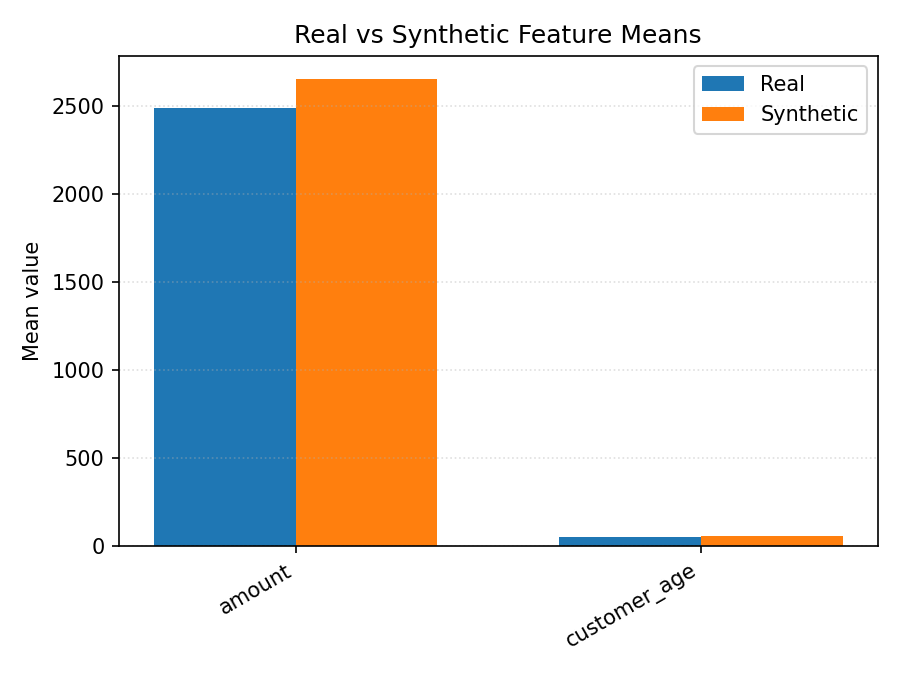

In [10]:
Image(filename=result["visualization_path"])